# Populating decoding-related hex maze tables

So you've done decoding for your hex maze session and have an entry in `DecodingOutput`.

## Now we can populate `HexMazeDecodedPosition` and `HexMazeDecodedPositionHex`!

#### `HexMazeDecodedPosition`

calculates most likely decoded position at each time point and stores a combined dataframe of actual and decoded position, decode confidence metrics (HPD threshold, spatial coverage of the 95% confidence region), and distance between decoded and actual position.

- `HexMazeDecodedPosition.fetch1_dataframe()` returns a dataframe with columns: 
    - position_x, position_y, orientation, velocity_x, velocity_y, speed, decode_position_x, decode_position_y, decode_distance, hpd_thresh, spatial_cov




#### `HexMazeDecodedPositionHex` 

assigns actual and decoded position from `HexMazeDecodedPosition` to a maze hex at each timepoint (using the current maze configuration to avoid assigning position to barriers or unreachable hexes). It stores a combined dataframe of everything in `HexMazeDecodedPosition` plus actual/decoded hex, hex distance between actual and decoded hex, and additional hex info (hex assignment including side hexes i.e. the half-hexes next to reward ports, distance from xy position to assigned hex centroid)

- `HexMazeDecodedPosition.fetch1_dataframe()` returns a dataframe with columns: 
    - position_x, position_y, orientation, velocity_x, velocity_y, speed, hex, decode_position_x, decode_position_y, decode_hex, decode_distance, decode_hex_distance, hpd_thresh, spatial_cov

- `HexMazeDecodedPosition.fetch1_dataframe_full()` returns a dataframe with columns: 
    - position_x, position_y, orientation, velocity_x, velocity_y, speed, hex, hex_including_sides, distance_from_centroid, decode_position_x, decode_position_y, decode_hex, decode_hex_including_sides, decode_distance_from_centroid, decode_distance, decode_hex_distance, hpd_thresh, spatial_cov 

In [ ]:
import matplotlib.pyplot as plt
import datajoint as dj
import numpy as np

import spyglass.common as sgc
from spyglass.decoding.decoding_merge import DecodingOutput

from spyglass_hexmaze.hex_maze_behavior import HexMazeBlock
from spyglass_hexmaze.hex_maze_decoding import (
    HexMazeDecodedPosition,
    HexMazeDecodedPositionHex,
)

# Make sure the session exists in the hex maze tables
nwb_file_name = "IM-1478_20220719_.nwb"
display(HexMazeBlock() & {"nwb_file_name": nwb_file_name})

/home/scrater/miniforge3/envs/spyglass/lib/python3.10/site-packages/datajoint/plugin.py:4: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources
[2026-03-25 18:14:30,955][INFO]: DataJoint 0.14.6 connected to scrater@lmf-db.cin.ucsf.edu:3306


nwb_file_name name of the NWB file,epoch the session epoch for this task and apparatus(1 based),block the block number within the epoch,config_id maze configuration as a string,interval_list_name descriptive name of this interval list,p_a probability of reward at port A,p_b probability of reward at port B,p_c probability of reward at port C,num_trials number of trials in this block,task_type 'barrier shift' or 'probabilty shift'
IM-1478_20220719_.nwb,0,1,"8,9,16,18,23,27,35,42,44",epoch0_block1,90.0,10.0,50.0,65,barrier change
IM-1478_20220719_.nwb,0,2,"8,9,18,21,23,27,35,42,44",epoch0_block2,90.0,10.0,50.0,62,barrier change
IM-1478_20220719_.nwb,0,3,"8,9,18,21,23,24,27,42,44",epoch0_block3,90.0,10.0,50.0,58,barrier change


View existing entries in `HexMazeDecodedPosition` and `HexMazeDecodedPositionHex`

In [ ]:
display(HexMazeDecodedPosition())
display(HexMazeDecodedPositionHex())

### Set up a key with `nwb_file_name`, `epoch`, and `decoding_merge_id`

`decoding_merge_id` is the `merge_id` that points to the `DecodingOutput` entry you want to use

In [3]:
decode_key = {"nwb_file_name": nwb_file_name} # can add other info like encoding_interval, decoding_interval, etc

all_decodes_for_this_nwb = DecodingOutput.merge_get_part(decode_key, multi_source=True)
print("\nAll entries for this nwb in DecodingOutput:")
display(all_decodes_for_this_nwb)

# all_decodes_for_this_nwb is a list
# Pick the one(s) you want to use for HexMazeDecodedPosition
decode_output = all_decodes_for_this_nwb[0] # here we take the first one

# Fetch results to make sure they exist
merge_id = decode_output.fetch("KEY")[0]
results = DecodingOutput.fetch_results(merge_id)

display(results)
print(f"Merge id: {merge_id}")


All entries for this nwb in DecodingOutput:


[*merge_id      nwb_file_name  unit_filter_pa sorted_spikes_ position_group decoding_param encoding_inter decoding_inter estimate_decod
 +------------+ +------------+ +------------+ +------------+ +------------+ +------------+ +------------+ +------------+ +------------+
 14fc3ff2-c6c4- IM-1478_202207 default_exclus sorted_spikes_ sorted_spikes_ contfrag_sorte 00_r1          00_r1          1             
 cd31d3b2-5b10- IM-1478_202207 default_exclus sorted_spikes_ sorted_spikes_ contfrag_sorte 00_r1          epoch0_block1  1             
  (Total: 2)]

[2026-03-25 18:15:28,794][WARNING]: Skipped checksum for file with hash: 4c6042f7-8d5c-efd9-5ee7-4c310323b9bf, and path: /stelmo/nwb/analysis/IM-1478_20220719/IM-1478_20220719_0e9dd4eb-2a5f-4baa-a214-051efce3fe41.nc


<xarray.Dataset> Size: 176GB
Dimensions:                      (time: 3521795, state_bins: 12464, states: 2,
                                  state_ind: 12464, states_from: 2, states_to: 2)
Coordinates:
  * time                         (time) float64 28MB 27.21 27.21 ... 7.071e+03
    interval_labels              (time) int32 14MB ...
  * state_ind                    (state_ind) int32 50kB 0 0 0 0 0 ... 1 1 1 1 1
  * states                       (states) object 16B 'Continuous' 'Fragmented'
  * states_from                  (states_from) object 16B 'Continuous' 'Fragm...
  * states_to                    (states_to) object 16B 'Continuous' 'Fragmen...
    environments                 (states) object 16B ...
    encoding_groups              (states) int32 8B ...
  * state_bins                   (state_bins) object 100kB MultiIndex
  * state                        (state_bins) object 100kB 'Continuous' ... '...
  * x_position                   (state_bins) float64 100kB 20.9 20.9 ... 182.1
  * y_position                   (state_bins) float64 100kB 5.046 7.02 ... 153.1
Data variables:
    acausal_posterior            (time, state_bins) float32 176GB ...
    acausal_state_probabilities  (time, states) float32 28MB ...
    initial_conditions           (state_bins) float64 100kB ...
    discrete_state_transitions   (states_from, states_to) float64 32B ...
Attributes:
    marginal_log_likelihoods:  [-11954218. -11916298. -11912283. -11911511.]

Merge id: {'merge_id': UUID('14fc3ff2-c6c4-3802-7faf-a92ca5f0dbaf')}


### Populate tables

Note calculating the most likely decoded x and y position and computing distance metrics requires loading the full (very large) posterior. Populating a single entry may take a long time, depending on how long your decoding interval is (1+ hour)

In [ ]:
# Create a key with nwb_file_name, epoch, and the merge_id from DecodingOutput
decoded_pos_key = {
    "decoding_merge_id": str(merge_id["merge_id"]),
    "nwb_file_name": nwb_file_name,
    "epoch": 0,
}
print(decoded_pos_key)

# Populate HexMazeDecodedPosition (1-2 hours)
HexMazeDecodedPosition.populate(decoded_pos_key)

# Populate HexMazeDecodedPositionHex (5-10 mins)
HexMazeDecodedPositionHex.populate(decoded_pos_key)

{'decoding_merge_id': '14fc3ff2-c6c4-3802-7faf-a92ca5f0dbaf', 'nwb_file_name': 'IM-1478_20220719_.nwb', 'epoch': 0}


[18:22:31][INFO] Spyglass: Writing new NWB file IM-1478_20220719_TG6KFC0QMV.nwb
INFO:spyglass:Writing new NWB file IM-1478_20220719_TG6KFC0QMV.nwb


{'success_count': 1, 'error_list': []}

Make sure it worked!

In [5]:
# Show our newly populated entry in the tables!
display(HexMazeDecodedPosition() & decoded_pos_key)
display(HexMazeDecodedPositionHex() & decoded_pos_key)

decoding_merge_id,nwb_file_name name of the NWB file,epoch the session epoch for this task and apparatus(1 based),analysis_file_name name of the file,decoded_position_object_id
14fc3ff2-c6c4-3802-7faf-a92ca5f0dbaf,IM-1478_20220719_.nwb,0,IM-1478_20220719_H0MH4LODEL.nwb,5c1cd78a-6eea-47d3-910d-cc1b4a520a87


decoding_merge_id,nwb_file_name name of the NWB file,epoch the session epoch for this task and apparatus(1 based),analysis_file_name name of the file,hex_assignment_object_id
14fc3ff2-c6c4-3802-7faf-a92ca5f0dbaf,IM-1478_20220719_.nwb,0,IM-1478_20220719_TG6KFC0QMV.nwb,fc404862-cf65-46ed-9a42-e25d08c2026e


## Fetching data

Fetch the newly populated dataframes for this entry

In [6]:
# Fetch the df of decoded and actual position
decoded_position_df = (HexMazeDecodedPosition & decoded_pos_key).fetch1_dataframe()
display(decoded_position_df)

# Fetch the df of decoded and actual position + hex info
decoded_position_and_hex_df = (HexMazeDecodedPositionHex & decoded_pos_key).fetch1_dataframe()
display(decoded_position_and_hex_df)

# Fetch the df of decoded and actual position + hex info + additional hex info (side hexes, distance from centroids)
decoded_position_and_hex_df_full = (HexMazeDecodedPositionHex & decoded_pos_key).fetch1_dataframe_full()
display(decoded_position_and_hex_df_full)

,position_x,position_y,orientation,velocity_x,velocity_y,speed,decode_position_x,decode_position_y,decode_distance,hpd_thresh,spatial_cov
time,,,,,,,,,,,
27.212204,127.830112,104.660579,1.154250,10.458841,39.534666,40.894708,112.459968,87.953792,-22.701499,0.001686,123
27.214204,127.855546,104.768322,1.153758,10.599990,39.454131,40.853253,112.459968,87.953792,-22.798075,0.001473,129
27.216204,127.880980,104.876064,1.153266,10.740744,39.366789,40.805731,112.459968,87.953792,-22.894779,0.001359,134
27.218204,127.906415,104.983807,1.152772,10.881101,39.272696,40.752215,112.459968,87.953792,-22.991610,0.001285,139
27.220204,127.931849,105.091549,1.152276,11.021062,39.171912,40.692782,112.459968,87.953792,-23.088565,0.001318,145
...,...,...,...,...,...,...,...,...,...,...,...
7070.791274,103.745313,14.701497,-1.862448,-0.290548,-0.014056,0.290888,46.772680,149.147500,-146.019206,0.002106,80
7070.793274,103.744672,14.697149,-1.862335,-0.244677,-0.007637,0.244796,46.772680,149.147500,-146.022959,0.001994,81
7070.795274,103.744031,14.692802,-1.862221,-0.198356,-0.000930,0.198358,46.772680,149.147500,-146.026712,0.001676,89


,position_x,position_y,orientation,velocity_x,velocity_y,speed,hex,decode_position_x,decode_position_y,decode_hex,decode_distance,decode_hex_distance,hpd_thresh,spatial_cov
time,,,,,,,,,,,,,,
27.212204,127.830112,104.660579,1.154250,10.458841,39.534666,40.894708,29,112.459968,87.953792,20,-22.701499,2,0.001686,123
27.214204,127.855546,104.768322,1.153758,10.599990,39.454131,40.853253,29,112.459968,87.953792,20,-22.798075,2,0.001473,129
27.216204,127.880980,104.876064,1.153266,10.740744,39.366789,40.805731,29,112.459968,87.953792,20,-22.894779,2,0.001359,134
27.218204,127.906415,104.983807,1.152772,10.881101,39.272696,40.752215,29,112.459968,87.953792,20,-22.991610,2,0.001285,139
27.220204,127.931849,105.091549,1.152276,11.021062,39.171912,40.692782,29,112.459968,87.953792,20,-23.088565,2,0.001318,145
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7070.791274,103.745313,14.701497,-1.862448,-0.290548,-0.014056,0.290888,1,46.772680,149.147500,49,-146.019206,15,0.002106,80
7070.793274,103.744672,14.697149,-1.862335,-0.244677,-0.007637,0.244796,1,46.772680,149.147500,49,-146.022959,15,0.001994,81
7070.795274,103.744031,14.692802,-1.862221,-0.198356,-0.000930,0.198358,1,46.772680,149.147500,49,-146.026712,15,0.001676,89


,position_x,position_y,orientation,velocity_x,velocity_y,speed,hex,hex_including_sides,distance_from_centroid,decode_position_x,decode_position_y,decode_hex,decode_hex_including_sides,decode_distance_from_centroid,decode_distance,decode_hex_distance,hpd_thresh,spatial_cov
time,,,,,,,,,,,,,,,,,,
27.212204,127.830112,104.660579,1.154250,10.458841,39.534666,40.894708,29,29,3.763525,112.459968,87.953792,20,20,3.741777,-22.701499,2,0.001686,123
27.214204,127.855546,104.768322,1.153758,10.599990,39.454131,40.853253,29,29,3.838145,112.459968,87.953792,20,20,3.741777,-22.798075,2,0.001473,129
27.216204,127.880980,104.876064,1.153266,10.740744,39.366789,40.805731,29,29,3.914474,112.459968,87.953792,20,20,3.741777,-22.894779,2,0.001359,134
27.218204,127.906415,104.983807,1.152772,10.881101,39.272696,40.752215,29,29,3.992414,112.459968,87.953792,20,20,3.741777,-22.991610,2,0.001285,139
27.220204,127.931849,105.091549,1.152276,11.021062,39.171912,40.692782,29,29,4.071872,112.459968,87.953792,20,20,3.741777,-23.088565,2,0.001318,145
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7070.791274,103.745313,14.701497,-1.862448,-0.290548,-0.014056,0.290888,1,1,3.133842,46.772680,149.147500,49,49_left,16.034266,-146.019206,15,0.002106,80
7070.793274,103.744672,14.697149,-1.862335,-0.244677,-0.007637,0.244796,1,1,3.138203,46.772680,149.147500,49,49_left,16.034266,-146.022959,15,0.001994,81
7070.795274,103.744031,14.692802,-1.862221,-0.198356,-0.000930,0.198358,1,1,3.142565,46.772680,149.147500,49,49_left,16.034266,-146.026712,15,0.001676,89


### Example analysis: plot actual and decoded position overlayed on the hex maze

We can do this for a subset of sessions, or all of the sessions in the `HexMazeDecodedPosition` table if you want to get crazy with it

In [ ]:
from spyglass_hexmaze.hex_maze_behavior import HexMazeBlock, HexCentroids
from spyglass_hexmaze.hex_maze_decoding import HexMazeDecodedPosition
from hexmaze import plot_hex_maze

# Set up some restriction if you want
restriction = "nwb_file_name LIKE '%IM-%'"  # e.g. for all Berke lab sessions
restriction = "nwb_file_name LIKE '%Toby%'" # e.g. for all Toby sessions
restriction = {"nwb_file_name": "IM-1478_20220725_.nwb", "epoch": 0} # e.g. for a specifc session
restriction = decoded_pos_key # e.g. for the session we just populated

# Get decode keys based on restriction
decode_keys = (HexMazeDecodedPosition() & restriction).fetch("KEY", order_by="nwb_file_name, epoch")
display(HexMazeDecodedPosition() & decode_keys)

decoding_merge_id,nwb_file_name name of the NWB file,epoch the session epoch for this task and apparatus(1 based),analysis_file_name name of the file,decoded_position_object_id
14fc3ff2-c6c4-3802-7faf-a92ca5f0dbaf,IM-1478_20220719_.nwb,0,IM-1478_20220719_H0MH4LODEL.nwb,5c1cd78a-6eea-47d3-910d-cc1b4a520a87


{'nwb_file_name': 'IM-1478_20220719_.nwb', 'epoch': 0, 'block': 1}: barrier change session for the hex maze task with 3 blocks and 185 trials.


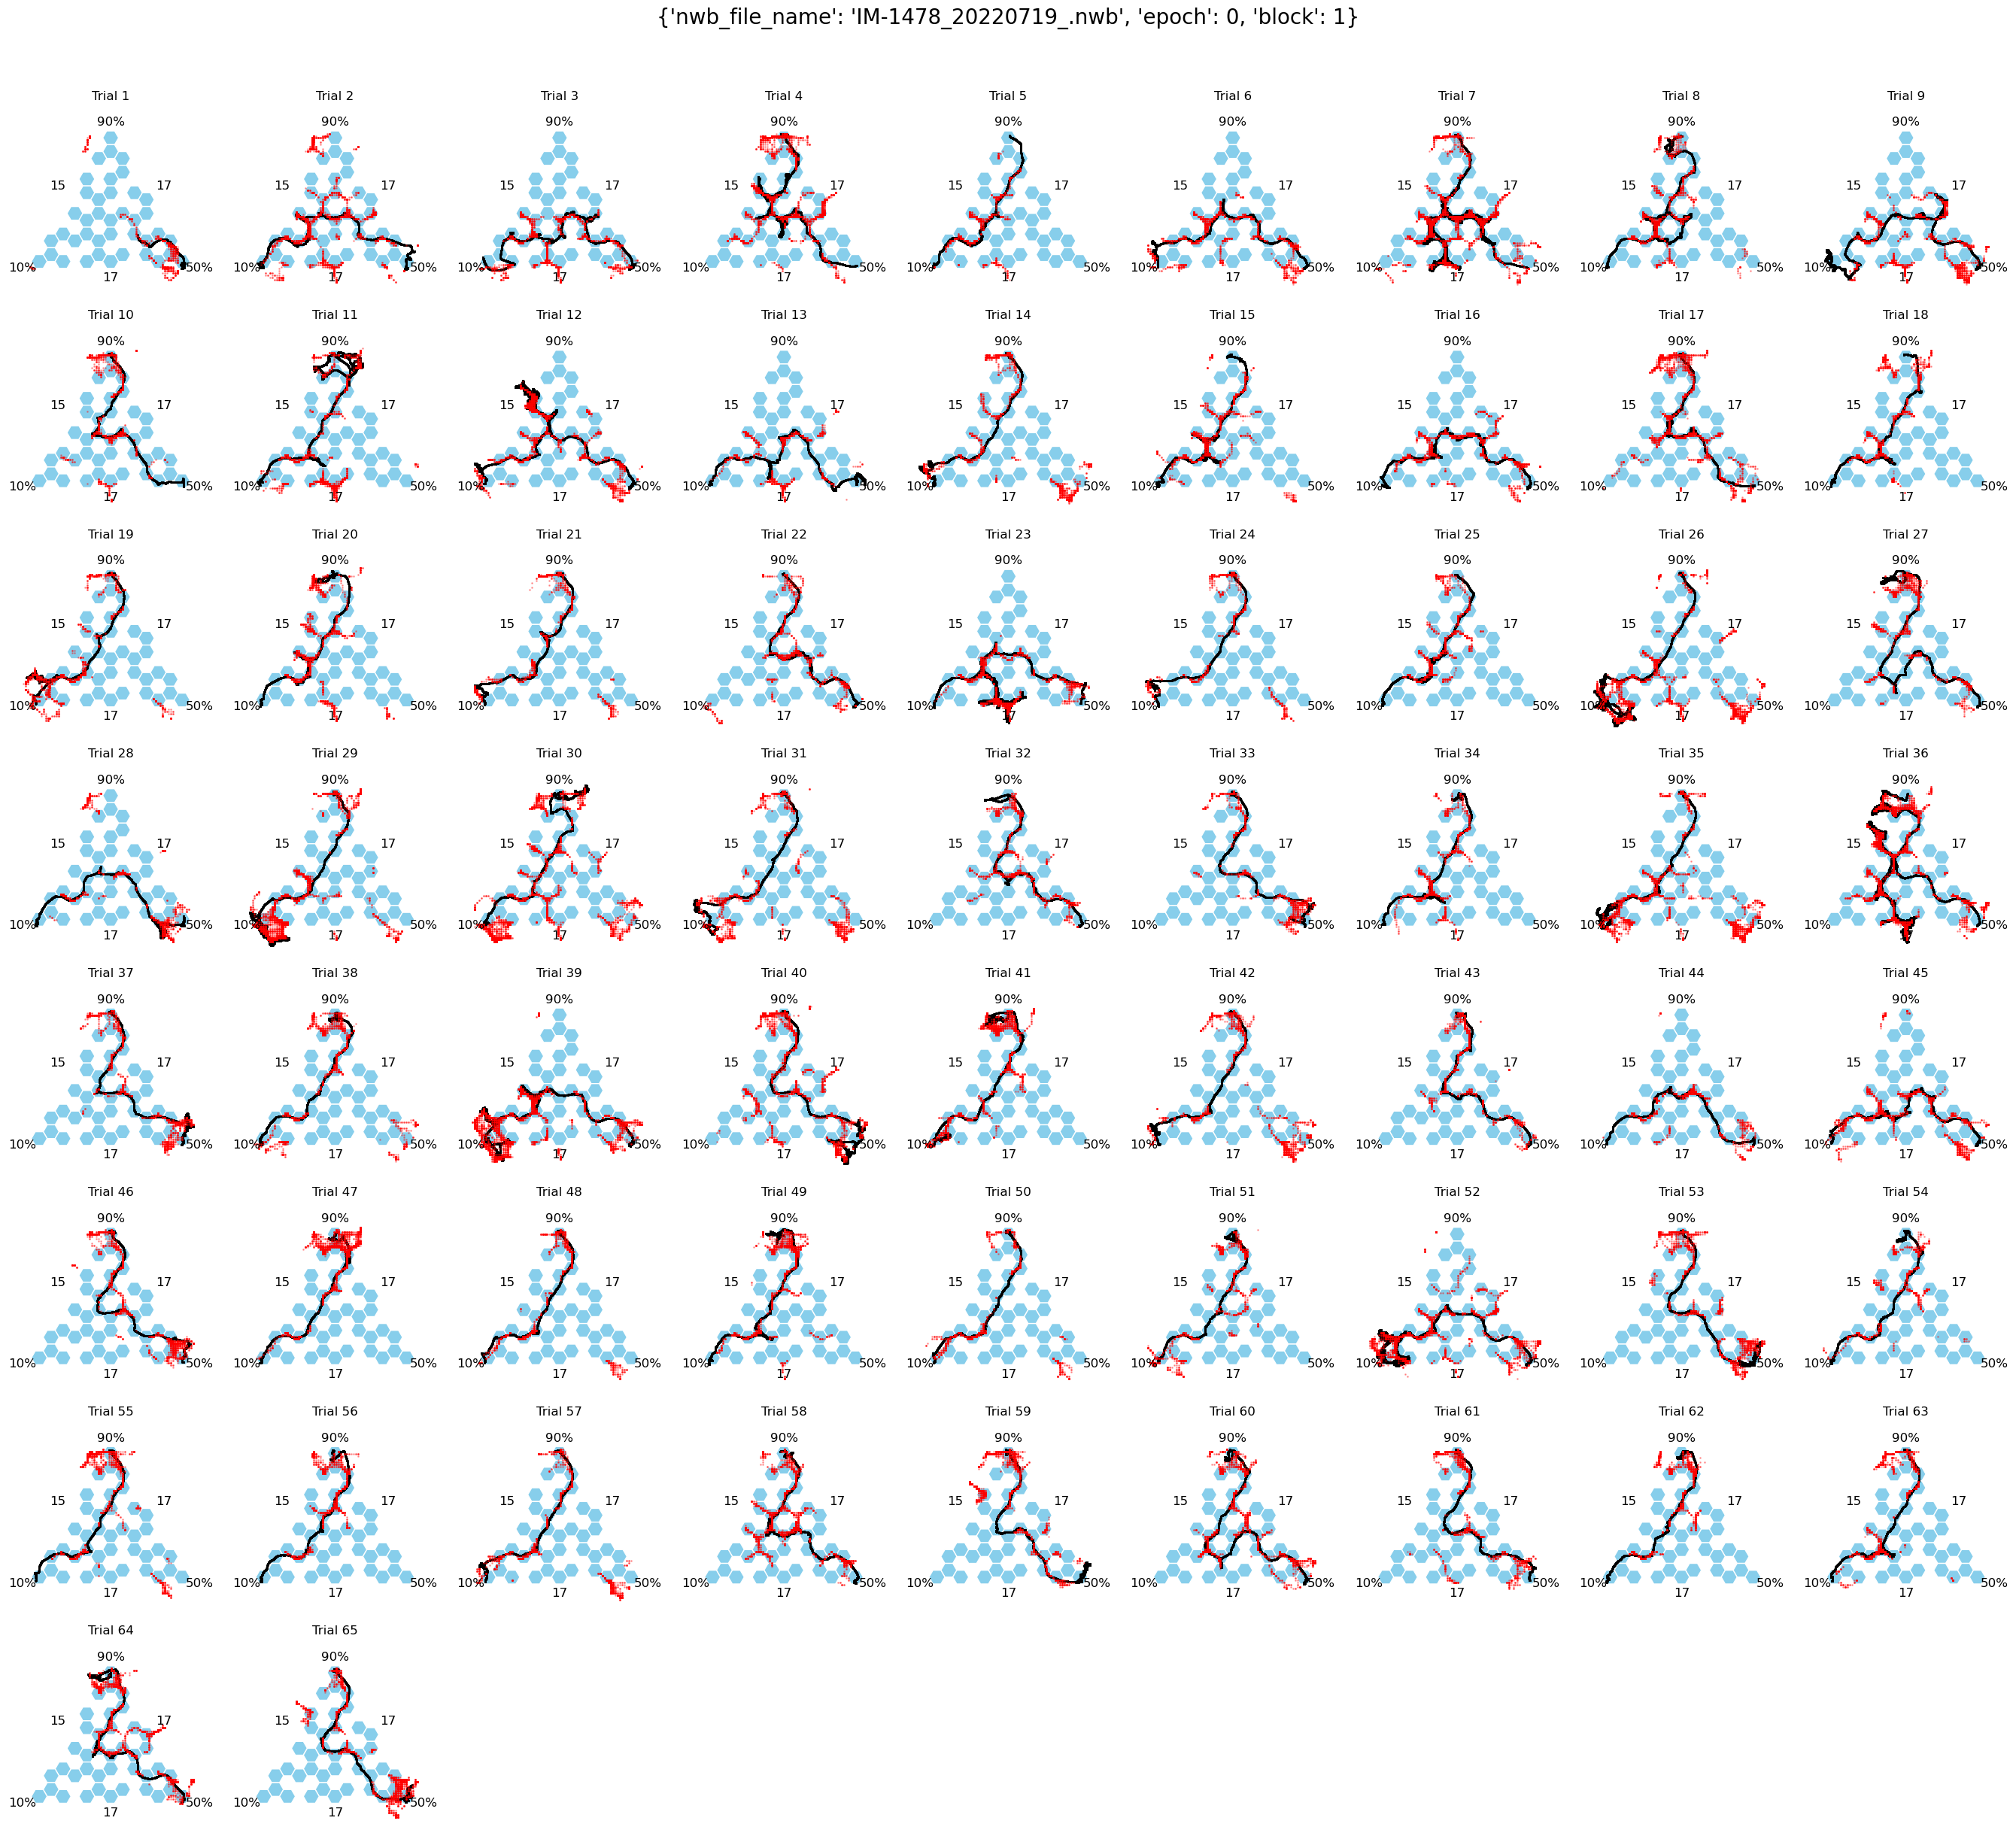

{'nwb_file_name': 'IM-1478_20220719_.nwb', 'epoch': 0, 'block': 2}: barrier change session for the hex maze task with 3 blocks and 185 trials.


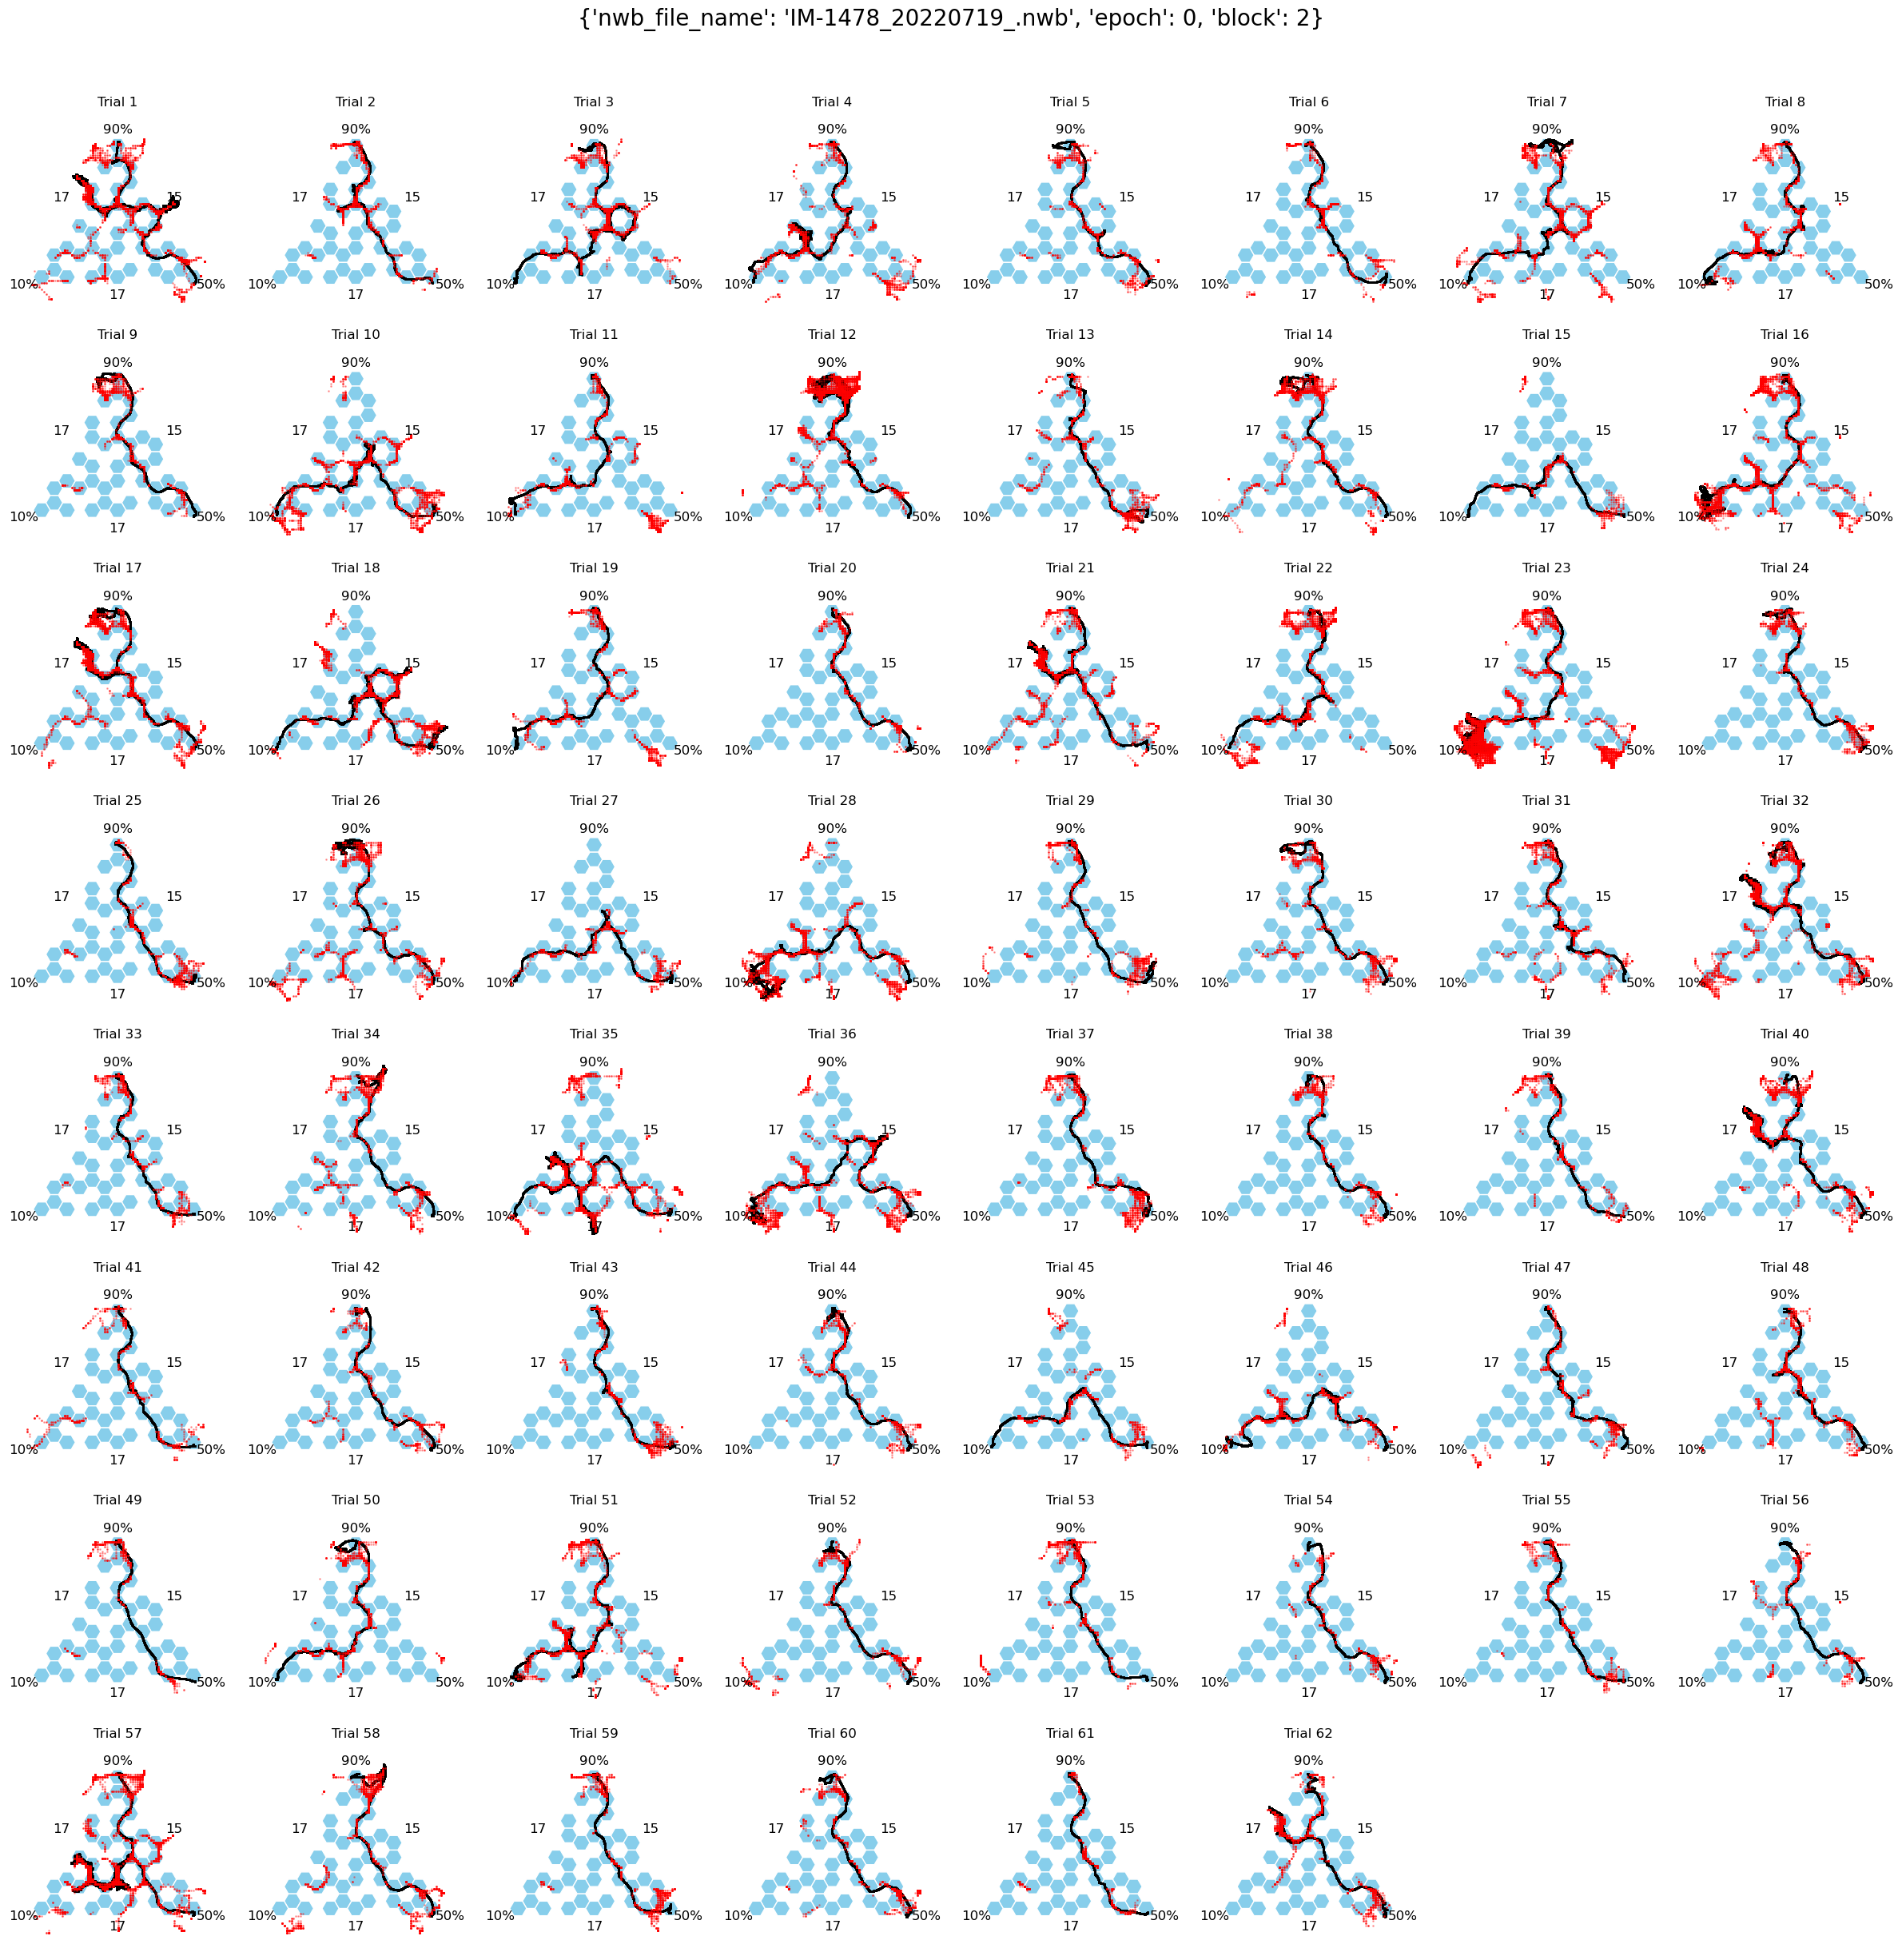

{'nwb_file_name': 'IM-1478_20220719_.nwb', 'epoch': 0, 'block': 3}: barrier change session for the hex maze task with 3 blocks and 185 trials.


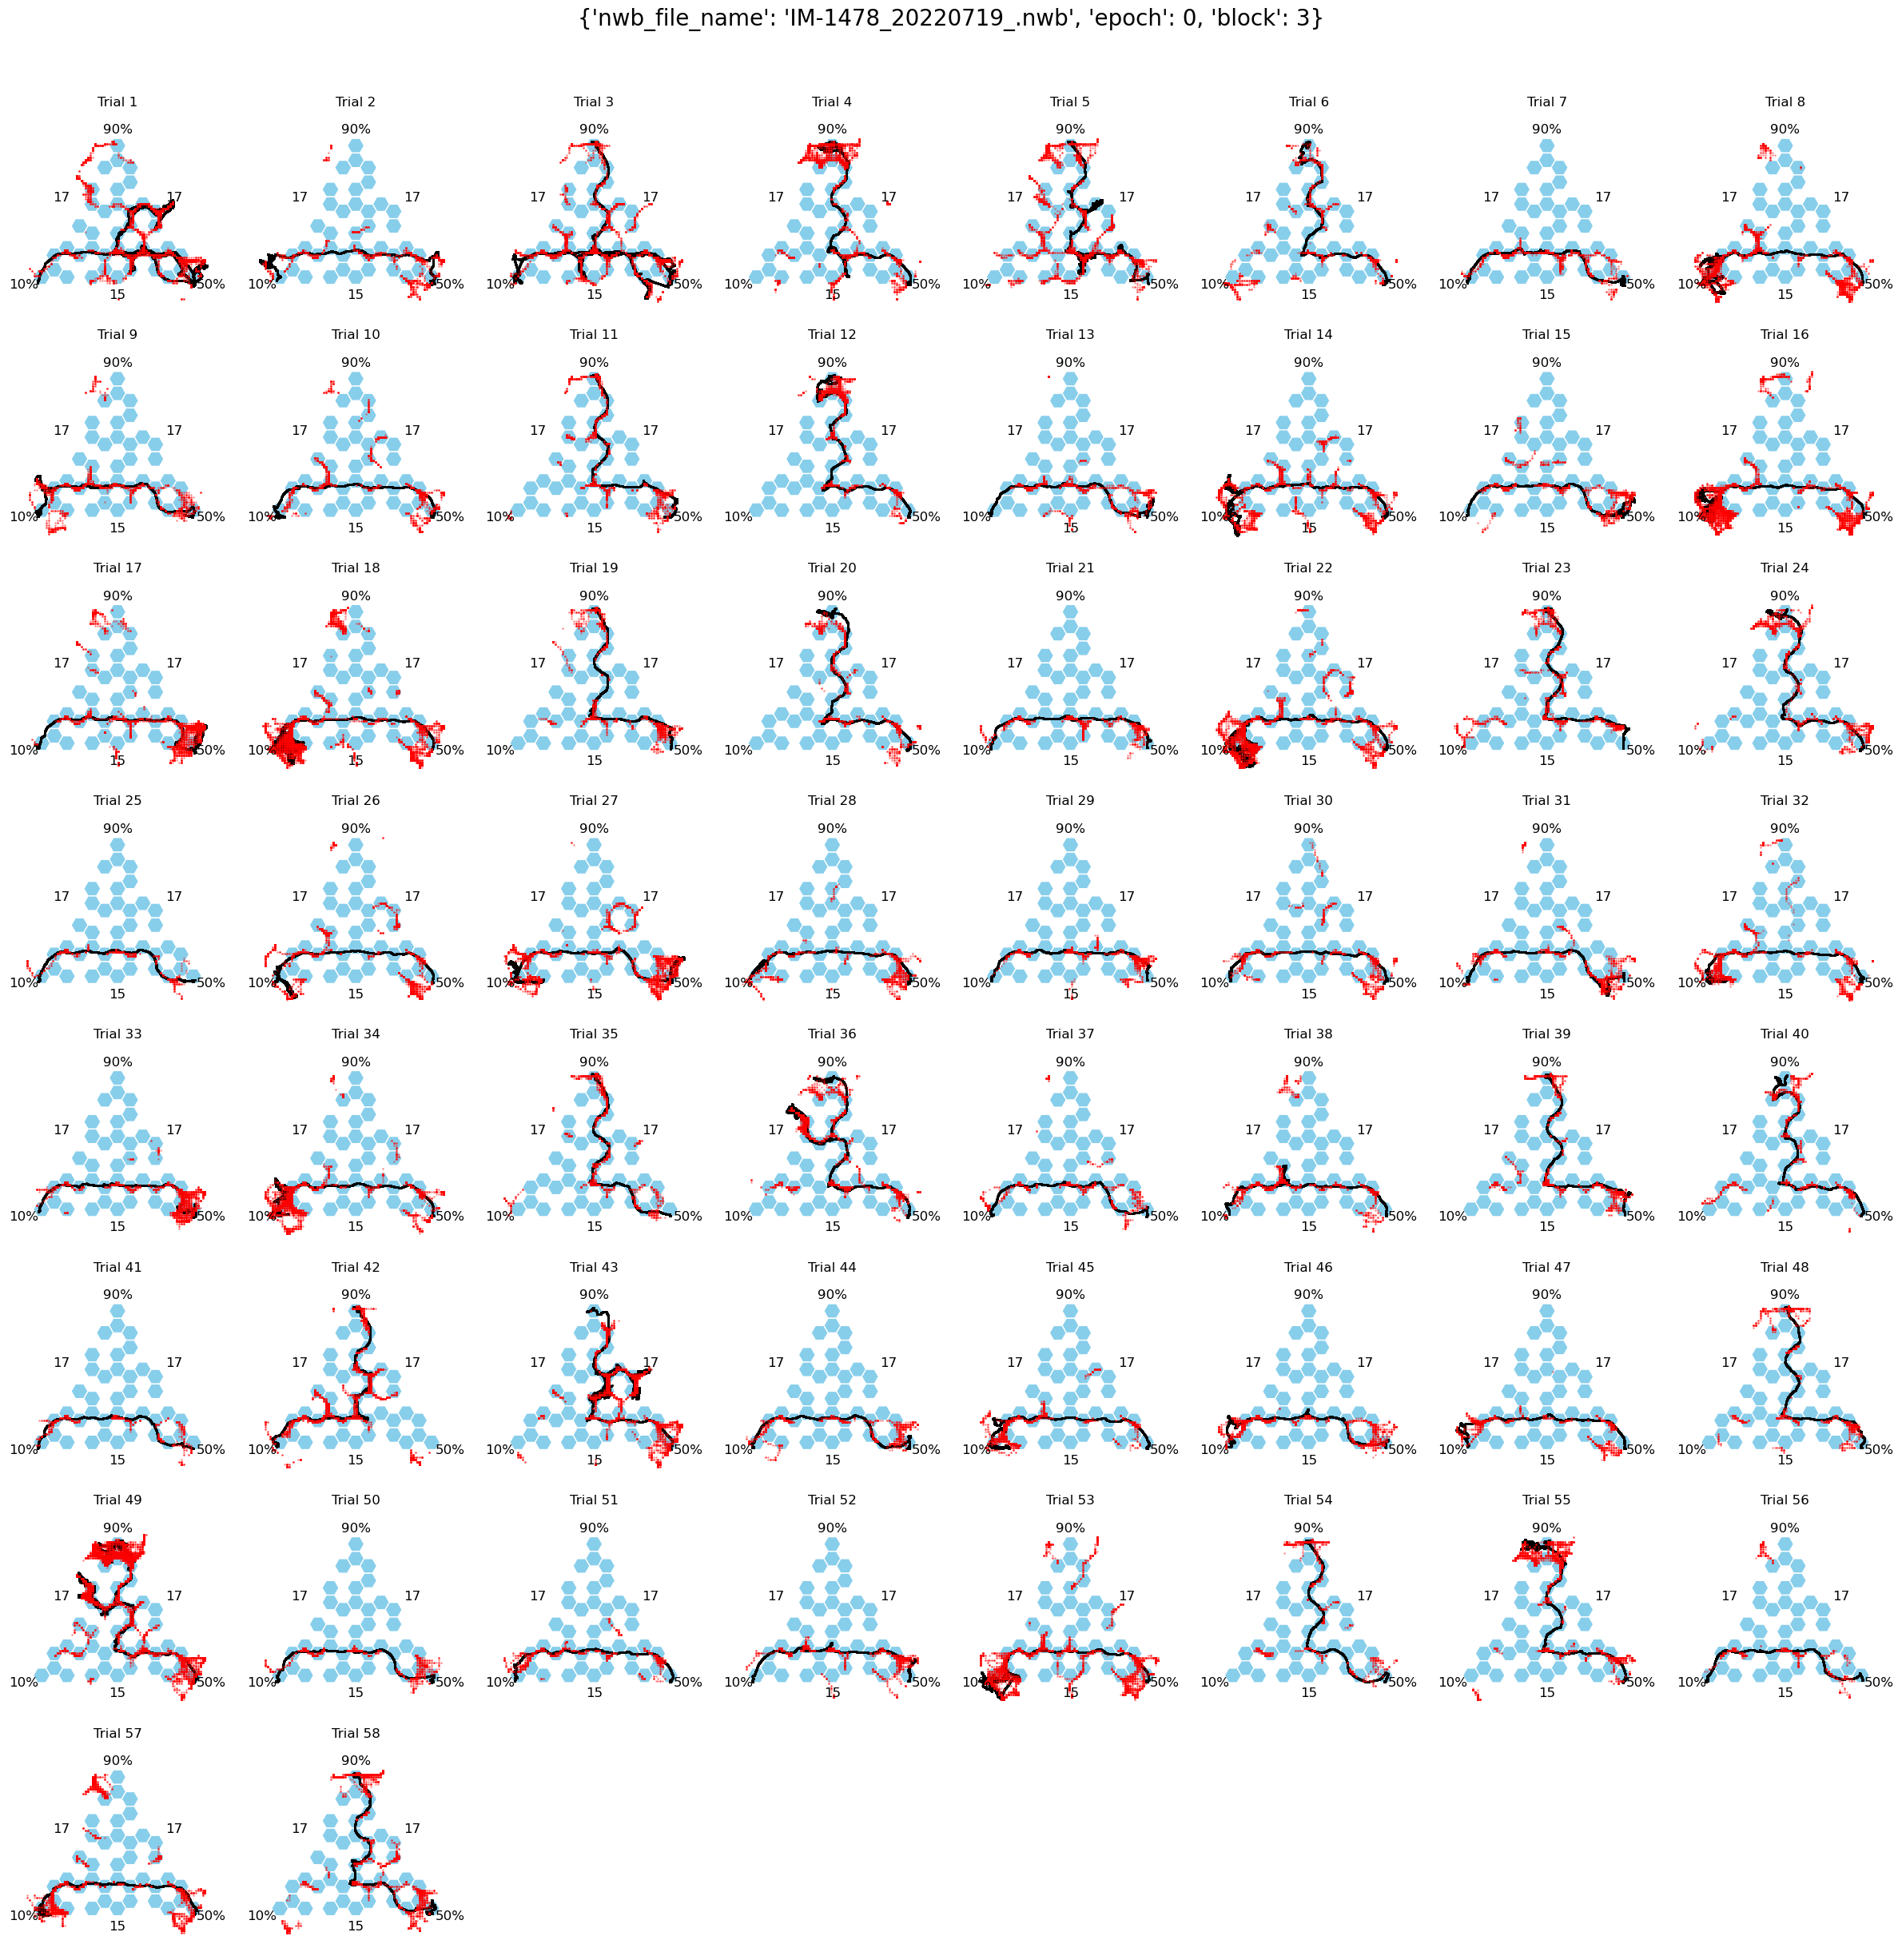

In [ ]:
# Only show decoded position if it meets these critera:
spatial_cov_threshold = 500 # 95% decode coverage must be less than this in cm2
speed_threshold = 2 # rat speed must be more than this in cm/s
decode_distance_threshold = 0 # decode distance from rat must be greater than this in cm

# Loop through blocks
for key in (HexMazeBlock() & decode_keys).fetch("KEY", order_by="nwb_file_name, epoch, block"):
    # Get block info
    print(f"{key}: {(sgc.Session() & key).fetch('session_description')[0]}")
    block = HexMazeBlock() & key
    trials = HexMazeBlock.Trial() & key
    num_trials = len(trials)
    maze, p_a, p_b, p_c = block.fetch1("config_id", "p_a", "p_b", "p_c")
    reward_probs = [int(p_a), int(p_b), int(p_c)]
    centroids = HexCentroids().get_core_hex_centroids_dict_cm(key)
    
    # Fetch actual and decoded position
    # (Note we would need to add decoding_merge_id to key if we have multiple entries for a nwb/epoch/block)
    pos_df = (HexMazeDecodedPosition() & key).fetch1_dataframe()
    
    # Set up square-ish grid for trials
    ncols = int(np.ceil(np.sqrt(num_trials)))
    nrows = int(np.ceil(num_trials / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(3 * ncols, 3 * nrows))

    # Make sure axes is 1D so flatten doesn't break
    if isinstance(axes, plt.Axes):
        axes = np.array([axes])
    else:
        axes = np.array(axes).flatten()

    # Big title
    fig.suptitle(f"{key}", fontsize=20, y=1.02)

    # Loop over trials
    for i, trial_info in enumerate(trials):
        # Get trial start/end
        start, end = (sgc.IntervalList() & trial_info).fetch1("valid_times")[0]
        df_trial = pos_df.loc[start:end]
        
        axes[i].set_title(f"Trial {i+1}")
        plot_hex_maze(
            ax=axes[i],
            barriers=maze,
            centroids=centroids,
            snap_centroids=True,
            invert_yaxis=True,
            show_barriers=False,
            show_hex_labels=False,
            show_stats=True,
            reward_probabilities=reward_probs,
        )
            
        # Plot actual position for this trial in black
        axes[i].scatter(df_trial["position_x"], df_trial["position_y"], s=1, color='k')
        # Filter decoded position based on our criteria
        pred = df_trial[
            (df_trial["spatial_cov"] < spatial_cov_threshold) &
            (df_trial["speed"] > speed_threshold) &
            (df_trial["decode_distance"] < decode_distance_threshold)
        ]
        # Plot decoded position for this trial in red
        axes[i].scatter(pred["decode_position_x"], pred["decode_position_y"], s=1, alpha=0.3, color="red")

    # Hide unused axes
    for j in range(num_trials, len(axes)):
        axes[j].axis("off")

    plt.tight_layout()
    plt.show()